- forward pass
- backward pass
- autotune
- проверка корректности
- benchmark против PyTorch

In [45]:
import time
import torch
import triton

print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [35]:
import torch
print(torch.__version__)

2.6.0+cu124


In [36]:
import math
import functools

import torch
import triton
import triton.language as tl

In [37]:
@triton.jit
def layernorm_forward_kernel(
    x_ptr,
    weight_ptr,
    bias_ptr,

    y_ptr,
    mean_ptr,
    rstd_ptr,

    stride_m,
    N,
    eps,

    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(0)

    row_start = pid * stride_m

    cols = tl.arange(0, BLOCK_SIZE)

    mask = cols < N

    x = tl.load(
        x_ptr + row_start + cols,
        mask=mask,
        other=0.0,
    ).to(tl.float32)

    mean = tl.sum(x, axis=0) / N

    x_centered = x - mean

    var = tl.sum(x_centered * x_centered, axis=0) / N

    rstd = 1.0 / tl.sqrt(var + eps)

    x_hat = x_centered * rstd

    weight = tl.load(
        weight_ptr + cols,
        mask=mask,
        other=1.0,
    ).to(tl.float32)

    bias = tl.load(
        bias_ptr + cols,
        mask=mask,
        other=0.0,
    ).to(tl.float32)

    y = x_hat * weight + bias

    tl.store(
        y_ptr + row_start + cols,
        y,
        mask=mask,
    )

    tl.store(mean_ptr + pid, mean)
    tl.store(rstd_ptr + pid, rstd)

In [38]:
def layernorm_forward(
    x,
    weight,
    bias,
    eps=1e-5,
):
    x = x.contiguous()

    M, N = x.shape

    BLOCK_SIZE = triton.next_power_of_2(N)

    y = torch.empty_like(x)

    mean = torch.empty(
        (M,),
        device=x.device,
        dtype=torch.float32,
    )

    rstd = torch.empty(
        (M,),
        device=x.device,
        dtype=torch.float32,
    )

    grid = (M,)

    layernorm_forward_kernel[grid](
        x,
        weight,
        bias,

        y,
        mean,
        rstd,

        x.stride(0),
        N,
        eps,

        BLOCK_SIZE=BLOCK_SIZE,
    )

    return y, mean, rstd

In [39]:
@triton.jit
def layernorm_backward_kernel(
    x_ptr,
    dy_ptr,

    weight_ptr,

    mean_ptr,
    rstd_ptr,

    dx_ptr,
    dweight_ptr,
    dbias_ptr,

    stride_m,
    N,

    BLOCK_SIZE: tl.constexpr,
):
    pid = tl.program_id(0)

    row_start = pid * stride_m

    cols = tl.arange(0, BLOCK_SIZE)

    mask = cols < N

    x = tl.load(
        x_ptr + row_start + cols,
        mask=mask,
        other=0.0,
    ).to(tl.float32)

    dy = tl.load(
        dy_ptr + row_start + cols,
        mask=mask,
        other=0.0,
    ).to(tl.float32)

    weight = tl.load(
        weight_ptr + cols,
        mask=mask,
        other=1.0,
    ).to(tl.float32)

    mean = tl.load(mean_ptr + pid)
    rstd = tl.load(rstd_ptr + pid)

    x_hat = (x - mean) * rstd

    wdy = weight * dy

    mean1 = tl.sum(wdy, axis=0) / N

    mean2 = tl.sum(wdy * x_hat, axis=0) / N

    dx = rstd * (
        wdy
        - mean1
        - x_hat * mean2
    )

    tl.store(
        dx_ptr + row_start + cols,
        dx,
        mask=mask,
    )

    dw = dy * x_hat
    db = dy

    tl.atomic_add(
        dweight_ptr + cols,
        dw,
        mask=mask,
    )

    tl.atomic_add(
        dbias_ptr + cols,
        db,
        mask=mask,
    )

In [40]:
def layernorm_backward(
    x,
    dy,
    weight,
    mean,
    rstd,
):
    M, N = x.shape

    BLOCK_SIZE = triton.next_power_of_2(N)

    dx = torch.empty_like(x)

    dweight = torch.zeros(
        weight.shape,
        device=weight.device,
        dtype=torch.float32,
    )

    dbias = torch.zeros(
        weight.shape,
        device=weight.device,
        dtype=torch.float32,
    )

    grid = (M,)

    layernorm_backward_kernel[grid](
        x,
        dy,

        weight,

        mean,
        rstd,

        dx,
        dweight,
        dbias,

        x.stride(0),
        N,

        BLOCK_SIZE=BLOCK_SIZE,
    )

    return dx, dweight, dbias

In [41]:
def layernorm_forward_torch(
    x,
    weight,
    bias,
    eps=1e-5,
):
    mean = x.mean(dim=-1, keepdim=True)

    var = x.var(
        dim=-1,
        unbiased=False,
        keepdim=True
    )

    rstd = 1.0 / torch.sqrt(var + eps)

    x_hat = (x - mean) * rstd

    return x_hat * weight + bias

In [42]:
torch.manual_seed(0)

M = 1024
N = 768

x = torch.randn(
    (M, N),
    device="cuda",
    dtype=torch.float16
)

weight = torch.randn(
    (N,),
    device="cuda",
    dtype=torch.float16
)

bias = torch.randn(
    (N,),
    device="cuda",
    dtype=torch.float16
)

y_triton, mean, rstd = layernorm_forward(
    x,
    weight,
    bias,
)

y_torch = layernorm_forward_torch(
    x,
    weight,
    bias,
)

torch.testing.assert_close(
    y_triton,
    y_torch,
    atol=1e-2,
    rtol=1e-2,
)

print("FORWARD OK")

FORWARD OK


In [43]:
x_ref = x.clone().detach().requires_grad_(True)

weight_ref = weight.clone().detach().requires_grad_(True)

bias_ref = bias.clone().detach().requires_grad_(True)

y_ref = layernorm_forward_torch(
    x_ref,
    weight_ref,
    bias_ref,
)

dy = torch.randn_like(y_ref)

y_ref.backward(dy)

dx_triton, dw_triton, db_triton = layernorm_backward(
    x,
    dy,
    weight,
    mean,
    rstd,
)

dw_triton = dw_triton.to(weight_ref.grad.dtype)
db_triton = db_triton.to(bias_ref.grad.dtype)

torch.testing.assert_close(
    dx_triton,
    x_ref.grad,
    atol=1e-2,
    rtol=1e-2,
)

torch.testing.assert_close(
    dw_triton,
    weight_ref.grad,
    atol=5e-2,
    rtol=5e-2,
)

torch.testing.assert_close(
    db_triton,
    bias_ref.grad,
    atol=1e-2,
    rtol=1e-2,
)

print("BACKWARD OK")

BACKWARD OK


In [46]:
M = 4096
N = 4096

x = torch.randn(
    (M, N),
    device="cuda",
    dtype=torch.float16
)

weight = torch.randn(
    (N,),
    device="cuda",
    dtype=torch.float16
)

bias = torch.randn(
    (N,),
    device="cuda",
    dtype=torch.float16
)

layer = torch.nn.LayerNorm(N).cuda().half()

layer.weight.data.copy_(weight)
layer.bias.data.copy_(bias)

for _ in range(10):
    y, _, _ = layernorm_forward(x, weight, bias)

torch.cuda.synchronize()

start = time.time()

for _ in range(100):
    y, _, _ = layernorm_forward(x, weight, bias)

torch.cuda.synchronize()

triton_time = time.time() - start

for _ in range(10):
    y = layer(x)

torch.cuda.synchronize()

start = time.time()

for _ in range(100):
    y = layer(x)

torch.cuda.synchronize()

torch_time = time.time() - start

print(f"Triton time: {triton_time:.4f} sec")
print(f"Torch  time: {torch_time:.4f} sec")
print(f"Speedup: {torch_time / triton_time:.2f}x")

Triton time: 0.4475 sec
Torch  time: 0.0305 sec
Speedup: 0.07x


In [52]:
import matplotlib.pyplot as plt

Ns = [256, 512, 1024, 2048, 4096]

triton_times = []
torch_times = []

M = 4096

for N in Ns:

    x = torch.randn(
        (M, N),
        device="cuda",
        dtype=torch.float16
    )

    weight = torch.randn(
        (N,),
        device="cuda",
        dtype=torch.float16
    )

    bias = torch.randn(
        (N,),
        device="cuda",
        dtype=torch.float16
    )

    layer = torch.nn.LayerNorm(N).cuda().half()

    layer.weight.data.copy_(weight)
    layer.bias.data.copy_(bias)

    for _ in range(10):
        y, _, _ = layernorm_forward(x, weight, bias)

    torch.cuda.synchronize()

    start = time.time()

    for _ in range(100):
        y, _, _ = layernorm_forward(x, weight, bias)

    torch.cuda.synchronize()

    triton_time = time.time() - start

    for _ in range(10):
        y = layer(x)

    torch.cuda.synchronize()

    start = time.time()

    for _ in range(100):
        y = layer(x)

    torch.cuda.synchronize()

    torch_time = time.time() - start

    triton_times.append(triton_time)
    torch_times.append(torch_time)

    print(f"N={N}")
    print(f"Triton: {triton_time:.4f}")
    print(f"Torch : {torch_time:.4f}")
    print()

N=256
Triton: 0.0442
Torch : 0.0630

N=512
Triton: 0.0130
Torch : 0.0220

N=1024
Triton: 0.0354
Torch : 0.0317

N=2048
Triton: 0.3448
Torch : 0.0166

N=4096
Triton: 0.0348
Torch : 0.0332



Сравнение времени выполнения Triton LayerNorm и PyTorch LayerNorm для различных значений hidden size.

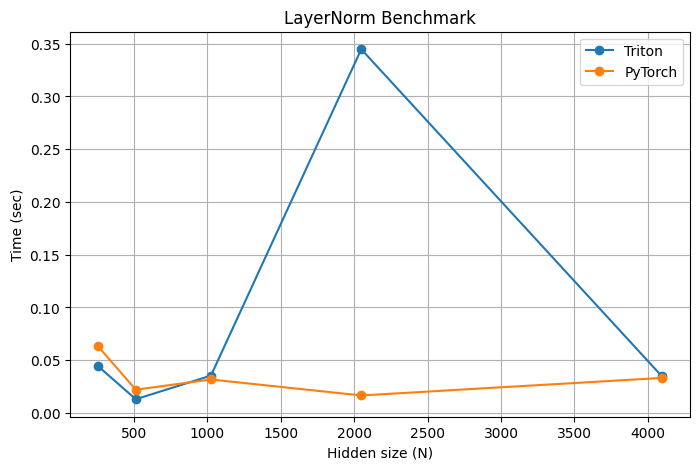

In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    Ns,
    triton_times,
    marker="o",
    label="Triton"
)

plt.plot(
    Ns,
    torch_times,
    marker="o",
    label="PyTorch"
)

plt.xlabel("Hidden size (N)")
plt.ylabel("Time (sec)")
plt.title("LayerNorm Benchmark")

plt.grid(True)
plt.legend()

plt.show()